# Empirical Example for Sensitivity Analysis: Gasoline Demand

This is an adaptation of the replication package for Chernozhukov, Cinelli, Newey, Sharma and Syrgkanis,
*Long Story Short: Omitted Variable Bias in Causal Machine Learning* 

The original replication package can be found __[here](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/VH6QHQ)__.

In [20]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.special
import joblib
from statsmodels.api import OLS
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import math
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LinearRegression, Lasso, LogisticRegression

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [22]:
from sensitivity import dml_sensitivity_bounds, dml_tvalue
from sensitivity import sensitivity_bounds, tvalue, sensitivity_contours
from debiased import DebiasedMoment
from econml.dml import LinearDML

In [23]:
from automl import reg_fn_gen, rr_fn_gen

## Setting

The data come from the 2001 National Household Travel Survey and contain household gasoline consumption, gasoline prices, income brackets, and 24 observed controls describing population density, urbanization, demographics, and Census regions. After the sample restrictions used in the earlier demand studies, the analysis contains 3,466 households.

The outcome $Y$ is log gasoline consumption, the treatment $D$ is log gasoline price, and $X^o$ collects the observed controls. Under conditional ignorability, the short regression is

$$g_s(d, x^o) = \mathrm{E}[Y \mid D = d, X^o = x^o],$$

and the target is the average causal derivative

$$\theta_s = \mathrm{E}\big\{\partial_d\, g_s(D, X^o)\big\}.$$

Because both variables are in logarithms, $\theta_s$ is the average price elasticity of gasoline demand. Its short Riesz representer is the negative conditional density score,

$$\alpha_s(D, X^o) = -\partial_d \log f_{D \mid X^o}(D \mid X^o).$$

The moment function below encodes $m(W_s, g) = \partial_d\, g(D, X^o)$. The derivative with respect to log price is approximated by a central finite difference, $\{g(D + \epsilon, X^o) - g(D - \epsilon, X^o)\}/(2\epsilon)$ with $\epsilon = 0.01$.

In [24]:
# The moment function, whose average we want to estimate: E[m(X; g)]
def moment_fn(x, test_fn):
    epsilon = 0.01
    t1 = np.hstack([x[:, [0]] + epsilon, x[:, 1:]])
    t0 = np.hstack([x[:, [0]] - epsilon, x[:, 1:]])
    return (test_fn(t1) - test_fn(t0)) / (2*epsilon)

## Data

Following the earlier demand studies, households with very low prices or incomes are dropped. Besides the full sample (`q=5`), the analysis uses four income groups. The first three (`q=1,2,3`) are overlapping groups centered near annual incomes of \$42,500, \$57,500 and \$72,500. The fourth (`q=4`) contains high-income households with income above roughly \$110,000 ($\log y \geq 11.6$).

Cross-validation and cross-fitting are grouped by state, so households from the same state remain in the same fold. The folds are stratified by Census region, and region dummies are included as controls.

In [25]:
# Data loading and manipulation

# for semi-synthetic data generation
def true_f(X):
    y = (-.7 - .4 * scipy.special.expit(3 * (1 - 2*(X[:, 1] - 10.5)))) * X[:, 0]
    y += scipy.special.expit(3 * (1 - 2 * (X[:, 1] > 11.5)))
    return y

# def true_f(X):
#     y = -.7 * X[:, 0]
#     y += scipy.special.expit(3 * (1 - 2 * (X[:, 1] > 11.5)))
#     return y

def get_data(q=None, synthetic=False, region=True, state=False, region_ids=None, random_seed=123):
    df = pd.read_csv('./BHP2017/data_BHP2_with_region.csv')
    # Throw away low prices and low income due to sample quality as in Chetverikov
    df = df[df["log_p"] > math.log(1.2)]
    df = df[df["log_y"] > math.log(15000)]
    if not ((q==4) | (q==5)): # all data in first three brackets
        df = df[df["log_y"] >= math.log(42500) - .5]
        df = df[df["log_y"] <= math.log(72500) + .5]
    if q == 1:
        df = df[df["log_y"] >= math.log(42500) - .5]
        df = df[df["log_y"] <= math.log(42500) + .5]
    if q == 2:
        df = df[df["log_y"] >= math.log(57500) - .5]
        df = df[df["log_y"] <= math.log(57500) + .5]
    if q == 3:
        df = df[df["log_y"] >= math.log(72500) - .5]
        df = df[df["log_y"] <= math.log(72500) + .5]
    if q == 4:
        df = df[df["log_y"] >= 11.6]
    if region_ids is not None: # Sub-select particular regions
        df = df[np.any([df['region'] == r for r in region_ids], axis=0)]
    Xdf = df.iloc[:, 1:] # Covariates
    X_nostatedum = Xdf.drop(["distance_oil1000", "share"], axis=1).values 
    if state: # whether to control for state id; almost no price variation left
        state_dum = pd.get_dummies(Xdf['state_fips'], prefix="state", drop_first=True)
        Xdf = pd.concat([Xdf, state_dum], axis = 1)
    if region: # whether to control for regrion id
        region_dum = pd.get_dummies(Xdf['region'], prefix="region", drop_first=True)
        Xdf = pd.concat([Xdf, region_dum], axis = 1)
    # Drop instrument and things we've one-hot encoded and weird share variable
    Xdf = Xdf.drop(["distance_oil1000", "state_fips", "share", 'region'], axis=1)
    column_names = Xdf.columns
    X = Xdf.values # to numpy array
    y = df['log_q'].values # outcome to numpy array
    if synthetic: # impute synthetic outcome based on known relationship
        y = true_f(X) + np.random.normal(0, .2, size=X[:, 0].shape)
        print(np.mean(moment_fn(X, true_f)))
    
    # Create state-block-wise and stratified by region folds for cross validation and cross fitting
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_seed)
    splits = list(cv.split(df, y=df['region'], groups=df['state_fips']))
    return X, y, [0, 1, 6, 7, 8], splits, column_names

In [26]:
# global result dictionaries and global parameters
ests = {}
res = {}
res_d = {}
q_grid = np.arange(1, 6)
synthetic = False # use synthetic outcome
verbose = 0
region = True # control for region

## Short Estimates Under Conditional Ignorability

In [27]:
# General pipeline for all types of estimators to generate the estimation result we want
def generic_pipeline(estimator, q_grid, name, n_seeds=5):
    ests = {}
    res = {}
    for q in q_grid:
        print(f'q={q}')
        ests[f'q={q}'] = []
        estimate_list = []
        for random_seed in np.arange(123, 123 + n_seeds):
            X, y, num_cols, splits, column_names = get_data(q, region=region, synthetic=synthetic, random_seed=random_seed)
            estimates, model = estimator(X, y, num_cols, splits)
            print(estimates)
            estimate_list.append(estimates)
            ests[f'q={q}'].append(model)
        estimate_list = np.array(estimate_list)
        res[f'q={q}'] = {}
        res[f'q={q}'][f'{name}'] = {}
        res[f'q={q}'][f'{name}']['point'] = np.mean(estimate_list[:, 0])
        if estimate_list.shape[1] > 2:
            res[f'q={q}'][f'{name}']['stderr'] = np.sqrt(np.mean(estimate_list[:, 1]**2) 
                                                         + np.var(estimate_list[:, 0]))
        res[f'q={q}'] = pd.DataFrame(res[f'q={q}']).transpose()
    return pd.concat(res), ests

In [28]:
# Transforming results to a nicely printable dataframe where each cell
# contains point (stderr) [ci_lower, ci_upper]
def transform_res_to_df(res, q_grid, alpha=None):
    res_f = res.reset_index()
    res_d = {}
    for q in q_grid:
        key = 'all <= 11.6' if q==0 else ('all' if q==5 else f'q={q}')
        res_d[key] = {}
        for method in np.unique(res_f['level_1'].values):
            p = res.loc[(f'q={q}', method), 'point']
            if alpha is not None:
                s = res.loc[(f'q={q}', method), 'stderr']
                error = scipy.stats.norm.ppf(1 - alpha) * s
                l, u = p - error, p + error
                res_d[key][method] = f"{p:.2f} ({s:.2f}) [{l:.2f}, {u:.2f}]"
            else:
                res_d[key][method] = f"{p:.2f}"
        
    return pd.DataFrame(res_d)

In [29]:
if synthetic:
    def oracle_estimator(X, y, num_cols, splits):
        return (np.mean(moment_fn(X, true_f)),), None
    res['true'], _ = generic_pipeline(oracle_estimator, q_grid, 'true', n_seeds=1)
    res_d['true'] = transform_res_to_df(res['true'], q_grid)
    display(res_d['true'])

### Nonparametric Model

The first specification leaves the short regression $g_s(D, X^o)$ unrestricted and targets $\theta_s = \mathrm{E}\{\partial_d g_s(D, X^o)\}$ directly. Rather than estimating the conditional density derivative in $\alpha_s$, which can be unstable, we learn the Riesz representer from the Riesz loss. Model selection is used for both the regression and the representer. Candidate procedures include expanded-feature lasso, forests and local polynomial forests for the regression, and penalized linear Riesz regression or ForestRiesz for the representer. The target and score stay fixed while the approximation class changes.

In [30]:
# fully non-parametric average derivative estimation
def nonlinrr(X, y, num_cols, splits):
    get_reisz_fn = rr_fn_gen(moment_fn, num_cols, cv=splits, verbose=verbose)
    get_reg_fn = reg_fn_gen(num_cols, cv=splits, verbose=verbose)
    est = DebiasedMoment(moment_fn=moment_fn,
                         get_reisz_fn=get_reisz_fn,
                         get_reg_fn=get_reg_fn,
                         n_splits=splits)
    est.fit(X, y)
    return est.avg_moment(alpha=.1), est

In [ ]:
res['rr'], ests['rr'] = generic_pipeline(nonlinrr, q_grid, 'dr')

In [32]:
res_d['rr'] = transform_res_to_df(res['rr'], q_grid, alpha=0.05)
res_d['rr']

,q=1,q=2,q=3,q=4,all
dr,"-0.56 (0.37) [-1.16, 0.04]","-0.77 (0.31) [-1.28, -0.26]","-0.78 (0.32) [-1.31, -0.25]","-1.84 (0.49) [-2.64, -1.04]","-0.57 (0.24) [-0.97, -0.18]"


### Partially Linear Model

The second specification is the partially linear model,

$$Y = \theta_s D + f_s(X^o) + \varepsilon, \qquad \mathrm{E}[\varepsilon \mid D, X^o] = 0,$$

in which the elasticity is constant.

In [33]:
# partially linear average derivative estimation, with doubleML
def dml_estimator(X, y, num_cols, splits):
    num_cols = [t - 1 for t in num_cols[1:]]
    model_y = reg_fn_gen(num_cols, cv=splits, verbose=verbose)(X[:, 1:], y)
    model_t = reg_fn_gen(num_cols, cv=splits, verbose=verbose)(X[:, 1:], X[:, 0])
    est = LinearDML(model_y=model_y(),
                    model_t=model_t(),
                    linear_first_stages=False,
                    cv=splits, random_state=123)
    est.fit(y, X[:, 0], W=X[:, 1:], cache_values=True)
    p = est.intercept__inference().point_estimate
    s = est.intercept__inference().stderr
    l, u = est.intercept__inference().conf_int(alpha=.1)
    return (p, s, l, u), est

In [ ]:
res['dml'], ests['dml'] = generic_pipeline(dml_estimator, q_grid, 'dml')

In [35]:
res_d['dml'] = transform_res_to_df(res['dml'], q_grid, alpha=.05)
res_d['dml']

,q=1,q=2,q=3,q=4,all
dml,"-0.45 (0.37) [-1.06, 0.17]","-0.85 (0.31) [-1.36, -0.33]","-0.78 (0.34) [-1.34, -0.22]","-1.94 (0.54) [-2.83, -1.06]","-0.84 (0.25) [-1.26, -0.43]"


## Sensitivity Results for the Full Sample

For the full sample we report the short elasticity, the sensitivity bounds and their confidence bounds under the scenario $C_Y^2 = 0.03$, $C_D^2 \approx 0.03$ and $|\rho| = 1$, together with robustness values.

In [36]:
table = {}
table['point'] = '{:.3f} ({:.3f})'.format(res['rr'].loc[(f'q={5}', 'dr'), 'point'],
                                          res['rr'].loc[(f'q={5}', 'dr'), 'stderr'])

est_list = ests['rr'][f'q={5}']
table['Bounds'] = '[{:.3f}, {:.3f}]'.format(*sensitivity_bounds(est_list, .03, .03, alpha=None))
table['CIBounds'] = '[{:.3f}, {:.3f}]'.format(*sensitivity_bounds(est_list, .03, .03, alpha=.05))
table['RV(v=-1.5)'] = '{:.3f}'.format(tvalue(est_list, value=-1.5, leq=True, alpha=None))
table['RV(v=-1.5,a=.05)'] = '{:.3f}'.format(tvalue(est_list, value=-1.5, leq=True, alpha=.05))
table['RV(v=0)'] = '{:.3f}'.format(tvalue(est_list, value=0, leq=False, alpha=None))
table['RV(v=0,a=.05)'] = '{:.3f}'.format(tvalue(est_list, value=0, leq=False, alpha=.05))

In [37]:
table2 = {}
table2['point'] = '{:.3f} ({:.3f})'.format(res['dml'].loc[(f'q={5}', 'dml'), 'point'],
                                          res['dml'].loc[(f'q={5}', 'dml'), 'stderr'])

est_list = ests['dml'][f'q={5}']
table2['Bounds'] = '[{:.3f}, {:.3f}]'.format(*dml_sensitivity_bounds(est_list, .03, .03, alpha=None))
table2['CIBounds'] = '[{:.3f}, {:.3f}]'.format(*dml_sensitivity_bounds(est_list, .03, .03, alpha=.05))
table2['RV(v=-1.5)'] = '{:.3f}'.format(dml_tvalue(est_list, value=-1.5, leq=True, alpha=None))
table2['RV(v=-1.5,a=.05)'] = '{:.3f}'.format(dml_tvalue(est_list, value=-1.5, leq=True, alpha=.05))
table2['RV(v=0)'] = '{:.3f}'.format(dml_tvalue(est_list, value=0, leq=False, alpha=None))
table2['RV(v=0,a=.05)'] = '{:.3f}'.format(dml_tvalue(est_list, value=0, leq=False, alpha=.05))

In [38]:
tabledf = pd.DataFrame({'Non-parametric': table, 'Partially linear': table2}).T[['point', 'Bounds', 'CIBounds',
                                                                                 'RV(v=-1.5)', 'RV(v=-1.5,a=.05)',
                                                                                 'RV(v=0)', 'RV(v=0,a=.05)']]
tabledf

,point,Bounds,CIBounds,RV(v=-1.5),"RV(v=-1.5,a=.05)",RV(v=0),"RV(v=0,a=.05)"
Non-parametric,-0.573 (0.240),"[-1.104, -0.043]","[-1.500, 0.350]",0.052,0.030,0.033,0.011
Partially linear,-0.844 (0.251),"[-1.299, -0.390]","[-1.712, 0.022]",0.043,0.017,0.055,0.029


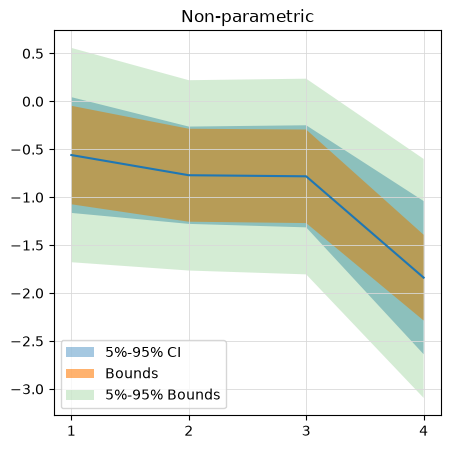

In [41]:
qgr = np.arange(1, 5)

point = [res['rr'].loc[(f'q={q}', 'dr'), 'point'] for q in qgr]
lower = [res['rr'].loc[(f'q={q}', 'dr'), 'point'] - 1.645*res['rr'].loc[(f'q={q}', 'dr'), 'stderr']
         for q in qgr]
upper = [res['rr'].loc[(f'q={q}', 'dr'), 'point'] + 1.645*res['rr'].loc[(f'q={q}', 'dr'), 'stderr']
         for q in qgr]
sens_band = [sensitivity_bounds(ests['rr'][f'q={q}'], .03, .03, alpha=None) for q in qgr]
sens_band_unc = [sensitivity_bounds(ests['rr'][f'q={q}'], .03, .03, alpha=.05) for q in qgr]

if synthetic:
    true_moment = [res['true'].loc[(f'q={q}', 'true'), 'point'] for q in qgr]

plt.figure(figsize=(5, 5))
plt.plot(qgr, point)
plt.fill_between(qgr, lower, upper, alpha=.4, label='5%-95% CI')
plt.fill_between(qgr, *list(zip(*sens_band)), alpha=.6, label='Bounds')
plt.fill_between(qgr, *list(zip(*sens_band_unc)), alpha=.2, label='5%-95% Bounds')
if synthetic:
    plt.plot(qgr, true_moment, label='true')
plt.xticks(qgr)
plt.title('Non-parametric')
plt.legend()
plt.grid(color = "0.85", linewidth = 0.6)

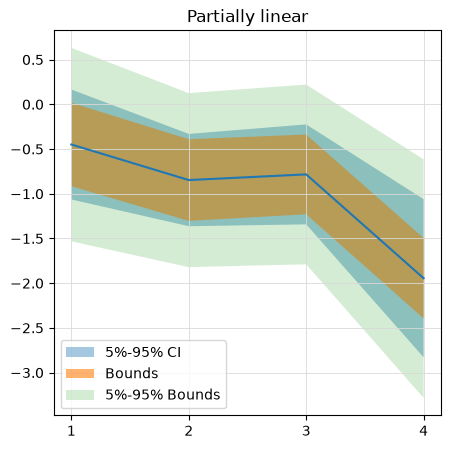

In [42]:
qgr = np.arange(1, 5)

point = [res['dml'].loc[(f'q={q}', 'dml'), 'point'] for q in qgr]
lower = [res['dml'].loc[(f'q={q}', 'dml'), 'point'] - 1.645*res['dml'].loc[(f'q={q}', 'dml'), 'stderr']
         for q in qgr]
upper = [res['dml'].loc[(f'q={q}', 'dml'), 'point'] + 1.645*res['dml'].loc[(f'q={q}', 'dml'), 'stderr']
         for q in qgr]
sens_band = [dml_sensitivity_bounds(ests['dml'][f'q={q}'], .03, .03, alpha=None) for q in qgr]
sens_band_unc = [dml_sensitivity_bounds(ests['dml'][f'q={q}'], .03, .03, alpha=.05) for q in qgr]

plt.figure(figsize=(5, 5))
plt.plot(qgr, point)
plt.fill_between(qgr, lower, upper, alpha=.4, label='5%-95% CI')
plt.fill_between(qgr, *list(zip(*sens_band)), alpha=.6, label='Bounds')
plt.fill_between(qgr, *list(zip(*sens_band_unc)), alpha=.2, label='5%-95% Bounds')
if synthetic:
    plt.plot(qgr, true_moment, label='true')
plt.xticks(qgr)
plt.title('Partially linear')
plt.legend()
plt.grid(color = "0.85", linewidth = 0.6)